# Глава 11

## Задание 11.3

In [89]:
import numpy as np

import os
import sys

PI2 = 2 * np.pi

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)

In [90]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

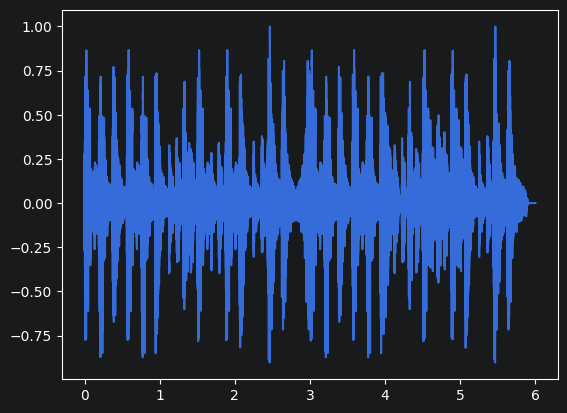

In [91]:
from thinkdsp import read_wave

wave = read_wave('263868__kevcio__amen-break-a-160-bpm.wav')
wave.normalize()
wave.plot()






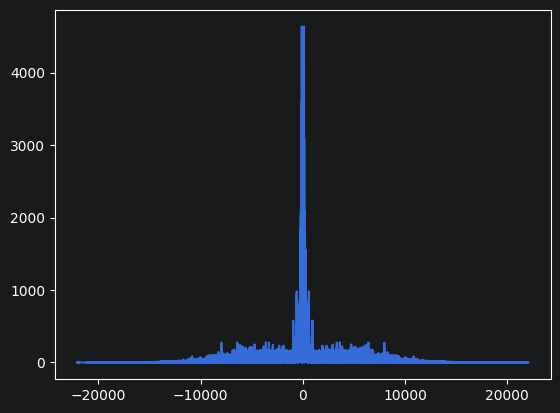

In [92]:
wave.make_audio()
spectrum = wave.make_spectrum(full=True)
spectrum.plot()

In [93]:
factor = 3
framerate = wave.framerate / factor
cutoff = framerate / 2 - 1


filtered = spectrum.make_wave()
filtered.make_audio()

In [94]:
from thinkdsp import Wave

def sample(wave, factor):

    ys = np.zeros(len(wave))
    ys[::factor] = np.real(wave.ys[::factor])
    return Wave(ys, framerate=wave.framerate)

sampled = sample(filtered, factor)
sampled.make_audio()



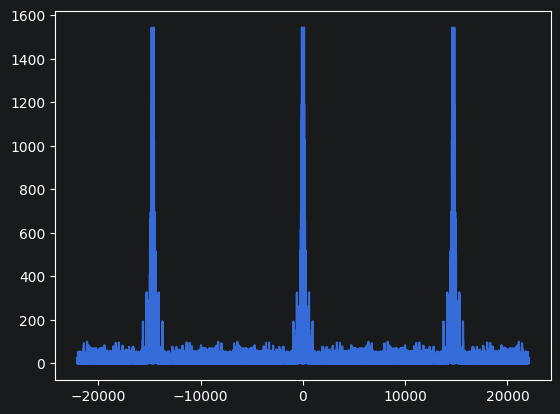

In [95]:
sampled_spectrum = sampled.make_spectrum(full=True)
sampled_spectrum.plot()

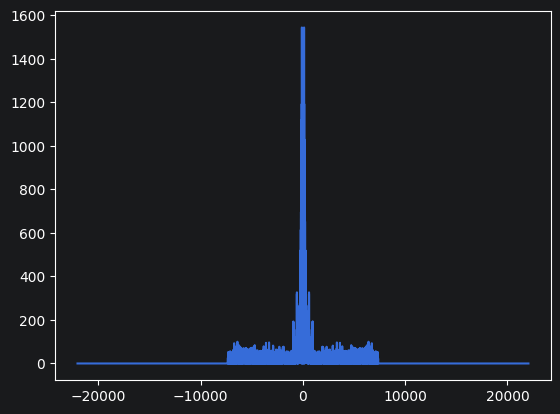

In [96]:
sampled_spectrum.low_pass(cutoff)
sampled_spectrum.plot()

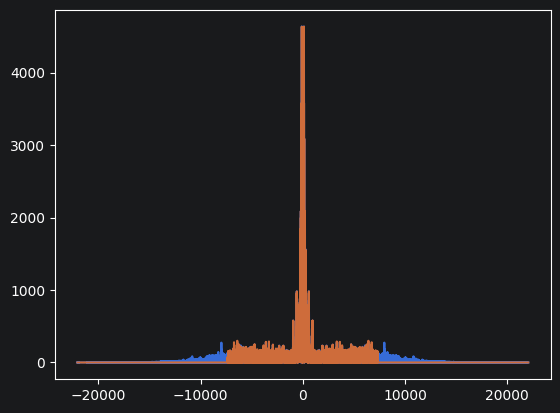

In [97]:
sampled_spectrum.scale(factor)
spectrum.plot()
sampled_spectrum.plot()

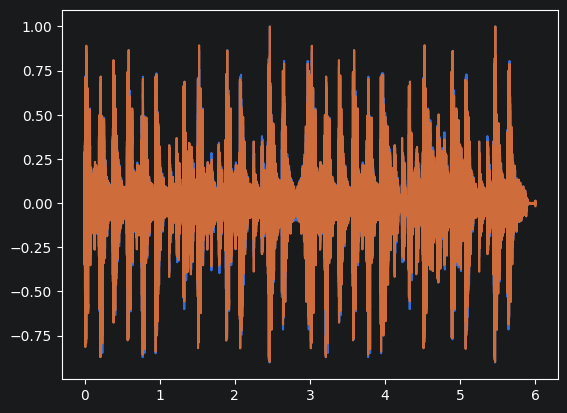

In [98]:
spectrum.max_diff(sampled_spectrum)

np.float64(273.7849555761336)

interpolated = sampled_spectrum.make_wave()
interpolated.make_audio()

filtered.plot()
interpolated.plot()



In [99]:
filtered.max_diff(interpolated)

np.float64(0.24964127415020587)